 Ideia principal do dataset

O conjunto de dados simula como clientes fazem pedidos na Starbucks em 100.000 compras, durante 2024 e 2025.

Ele foi criado para analisar o comportamento de compra dos clientes, comparando canais digitais e físicos.

📱 Canais de pedido analisados

O dataset registra como o cliente fez o pedido:

Mobile App → aplicativo do celular

Drive-Thru → pedido no carro

In-Store → dentro da loja

Kiosk → totens de autoatendimento

Isso permite estudar como as pessoas estão migrando para pedidos digitais.

👥 Informações do cliente

O dataset também possui dados como:

idade

tipo de cliente

localização da loja

membro do programa de recompensas

Isso ajuda a entender quem usa mais cada tipo de pedido.

☕ Informações do pedido

Cada compra também possui detalhes como:

quantidade de itens

personalizações da bebida (ex: leite diferente, menos açúcar)

tempo de preparo

valor total gasto

Isso permite analisar hábitos de consumo.

📈 Digital Venti Effect

O dataset tenta simular um fenômeno chamado “Digital Venti Effect”.

Significa que clientes que usam o aplicativo tendem a:

gastar mais dinheiro

fazer mais personalizações

ter padrões diferentes de idade

Ou seja:

👉 quem pede pelo celular geralmente compra mais coisas.

🧠 Em resumo

O dataset serve para estudar:

comportamento de compra de clientes

diferença entre pedidos digitais e presenciais

padrões de consumo

otimização de operações de loja

Baixando panda e detalhando meus dados
---

In [1]:
!mamba install pandas 
import pandas as pd

# Ler o arquivo CSV
df = pd.read_csv("starbucks_customer_ordering_patterns.csv")

# Número de instâncias (linhas)
print("Número de instâncias:", df.shape[0])

# Número de atributos (colunas)
print("Número de atributos:", df.shape[1])

# nome das colunas
print("Nome das colunas:",df.columns)

# Tipos de dados das colunas
print("\nTipos de dados:")
print(df.dtypes)

# Verificar se existem dados faltantes
print("Possui dados faltantes?", df.isnull().values.any())

# Mostrar quantidade de dados faltantes por coluna
print("\nDados faltantes por coluna:")
print(df.isnull().sum())


# Verificar se existem dados categóricos
print("\nPossui dados categóricos?",
      len(df.select_dtypes(include='object').columns) > 0)

#cart_size,

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 4.952200000047684 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
Número de instâncias: 100000
Número de atributos: 20
Nome das colunas: Index(['customer_id', 'order_id', 'order_date', 'order_time', 'day_of_week',
       'order_channel', 'st

/tmp/xpython_42/2621329941.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(df.select_dtypes(include='object').columns) > 0)



Possui dados categóricos? True


Fazendo Tratamento de dados
---



In [2]:
import pandas as pd

# Ler o dataset
df = pd.read_csv("starbucks_customer_ordering_patterns.csv")

# -------------------------
# 1 Número de instâncias
# -------------------------
print("Número de instâncias:", df.shape[0])

# -------------------------
# 2 Número de atributos
# -------------------------
print("Número de atributos:", df.shape[1])

# -------------------------
# 3 Verificar dados faltantes
# -------------------------
print("\nDados faltantes por coluna:")
print(df.isnull().sum())

# -------------------------
# 4 Verificar duplicatas
# -------------------------
duplicatas = df.duplicated().sum()
print("\nNúmero de linhas duplicadas:", duplicatas)

# -------------------------
# 5 Tipos de dados
# -------------------------
print("\nTipos de dados:")
print(df.dtypes)

# -------------------------
# 6 Verificar colunas categóricas
# -------------------------
categoricas = df.select_dtypes(include=['object','string']).columns

print("\nColunas categóricas:", list(categoricas))

for col in categoricas:
    print(f"\nValores únicos em {col}:")
    print(df[col].value_counts().head())

Número de instâncias: 100000
Número de atributos: 20

Dados faltantes por coluna:
customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64

Número de linhas duplicadas: 0

Tipos de dados:
customer_id                  str
order_id                     str
order_date                   str
order_time                   str
day_of_week                  str
order_channel                str
store_id                     str
store_location_type          str
region                       str
customer_age_group 

Tratamento e Análise Inicial dos Dados

Inicialmente foi realizada uma análise exploratória do conjunto de dados starbucks_customer_ordering_patterns.csv, com o objetivo de compreender sua estrutura e verificar possíveis inconsistências.


Primeiramente, foi verificado o número de instâncias (linhas) e o número de atributos (colunas) presentes no dataset, permitindo entender o tamanho e a dimensionalidade dos dados utilizados na análise.


Em seguida, foi realizada a verificação de dados faltantes (missing values) utilizando funções da biblioteca Pandas, identificando se existiam valores nulos nas colunas e quantificando quantos valores ausentes estavam presentes em cada atributo.


Também foi feita a verificação de linhas duplicadas, com o objetivo de identificar registros repetidos que poderiam comprometer a qualidade da análise. Caso existam duplicatas, elas podem ser removidas para evitar distorções nos resultados.


Posteriormente, foram analisados os tipos de dados de cada coluna, permitindo identificar atributos numéricos e categóricos. Essa etapa é importante para definir quais técnicas de tratamento ou transformação podem ser aplicadas posteriormente.


Por fim, foram identificadas as colunas categóricas e analisados alguns de seus valores únicos, permitindo compreender melhor as categorias presentes no conjunto de dados.


Essas etapas constituem o tratamento inicial e verificação básica da qualidade dos dados, sendo fundamentais para garantir que o dataset esteja adequado para análises posteriores ou aplicação de técnicas de ciência de dados.


ordering_channel é o rotulo que estarei utilizando para trabalhar com os dados de pedidos no meio digital


⚫ Redução dos dados
– Compressão de atributos
– Redução do número de dados
⚫ Transformação dos dados
– Padronização
– Normalização
– Matriz de correlação 
---

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.2206999999284744 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.6                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                        1.5.3

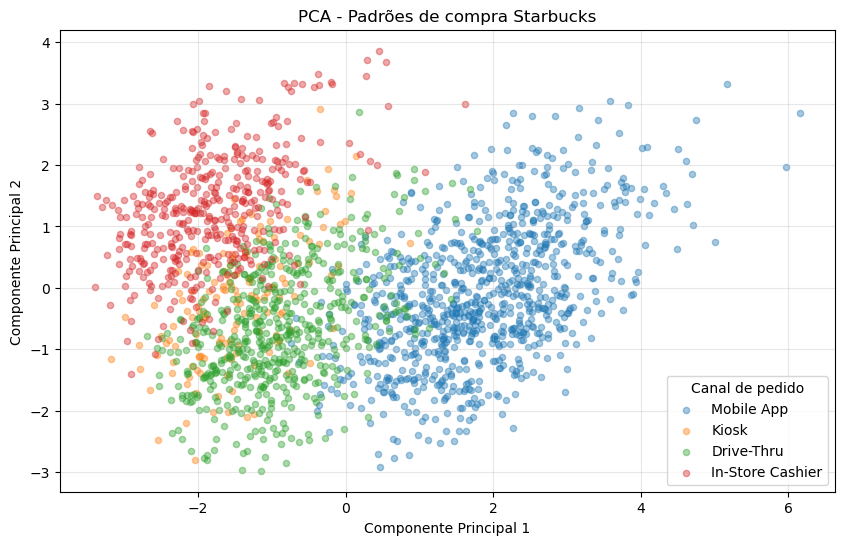

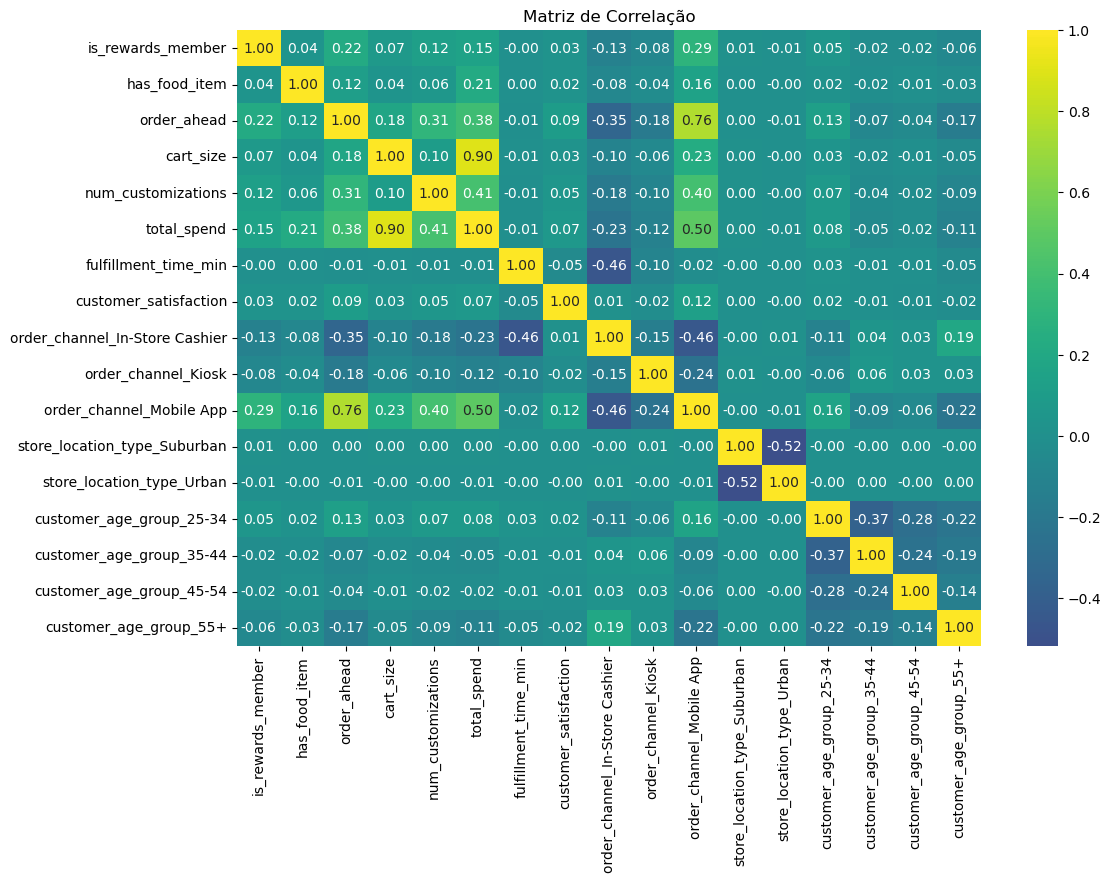

In [3]:
!mamba install scikit-learn 
!mamba install seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
# -------------------------
# Selecionar colunas
# -------------------------
df_model = df[['order_channel',
               'store_location_type',
               'customer_age_group',
               'is_rewards_member',
               'has_food_item',
               'order_ahead',
               'cart_size',
               'num_customizations',
               'total_spend',
               'fulfillment_time_min',
               'customer_satisfaction']].copy()

# -------------------------
# Guardar canal do pedido
# -------------------------
channels = df_model['order_channel']

# -------------------------
# Converter variáveis categóricas
# -------------------------
df_model = pd.get_dummies(df_model, drop_first=True)

# -------------------------
# Normalização
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# -------------------------
# PCA
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------
# Criar DataFrame
# -------------------------
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['order_channel'] = channels.values

# -------------------------
# Variância explicada
# -------------------------
print("Variância explicada por componente:")
print(pca.explained_variance_ratio_)

print("\nVariância total explicada:")
print(sum(pca.explained_variance_ratio_))

# -------------------------
# Amostra para visualização
# -------------------------
sample_df = pca_df.sample(2000, random_state=42)

# -------------------------
# Gráfico PCA
# -------------------------
plt.figure(figsize=(10,6))

for channel in sample_df['order_channel'].unique():

    subset = sample_df[sample_df['order_channel'] == channel]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        alpha=0.4,
        s=20,
        label=channel
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA - Padrões de compra Starbucks")

plt.legend(title="Canal de pedido")
plt.grid(alpha=0.3)

plt.show()

# -------------------------
# NÃO ESTUDADO AINDA
# -------------------------

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'],
    index=df_model.columns
)

# -------------------------
# Matriz de correlção
# -------------------------

corr_matrix = df_model.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='viridis', center=0)
plt.title('Matriz de Correlação')
plt.show()


# Aula 4 — Análise Descritiva de Dados

> **Referência:** Prof. Dr. Murilo Varges da Silva — Mineração de Dados, IFSP Campus Birigui

A Análise Descritiva de Dados (ADD) é utilizada para **descrever**, **simplificar** e **sumarizar** as principais características de uma base de dados.  
O processo é dividido em três passos:
1. Organizar os dados usando **distribuições de frequência**
2. Apresentar os dados usando **técnicas de visualização**
3. Calcular **medidas de tendência central**, variação e associação _(próxima aula)_

---

,Classes (Gasto $),Freq. Absoluta (Fi),Freq. Relativa (%),Freq. Acumulada (Fac),Freq. Relativa Acumulada (%)
0,"[0, 10)","19,398",19.40%,19398,19.400000
1,"[10, 20)","63,387",63.39%,82785,82.790000
2,"[20, 30)","16,142",16.14%,98927,98.930000
3,"[30, 40)","1,072",1.07%,99999,100.000000
4,"[40, 50)",1,0.00%,100000,100.000000
5,"[50, 60)",0,0.00%,100000,100.000000
6,"[60, 70)",0,0.00%,100000,100.000000
7,"[70, 80)",0,0.00%,100000,100.000000
8,"[80, 90)",0,0.00%,100000,100.000000
9,"[90, 100]",0,0.00%,100000,100.000000


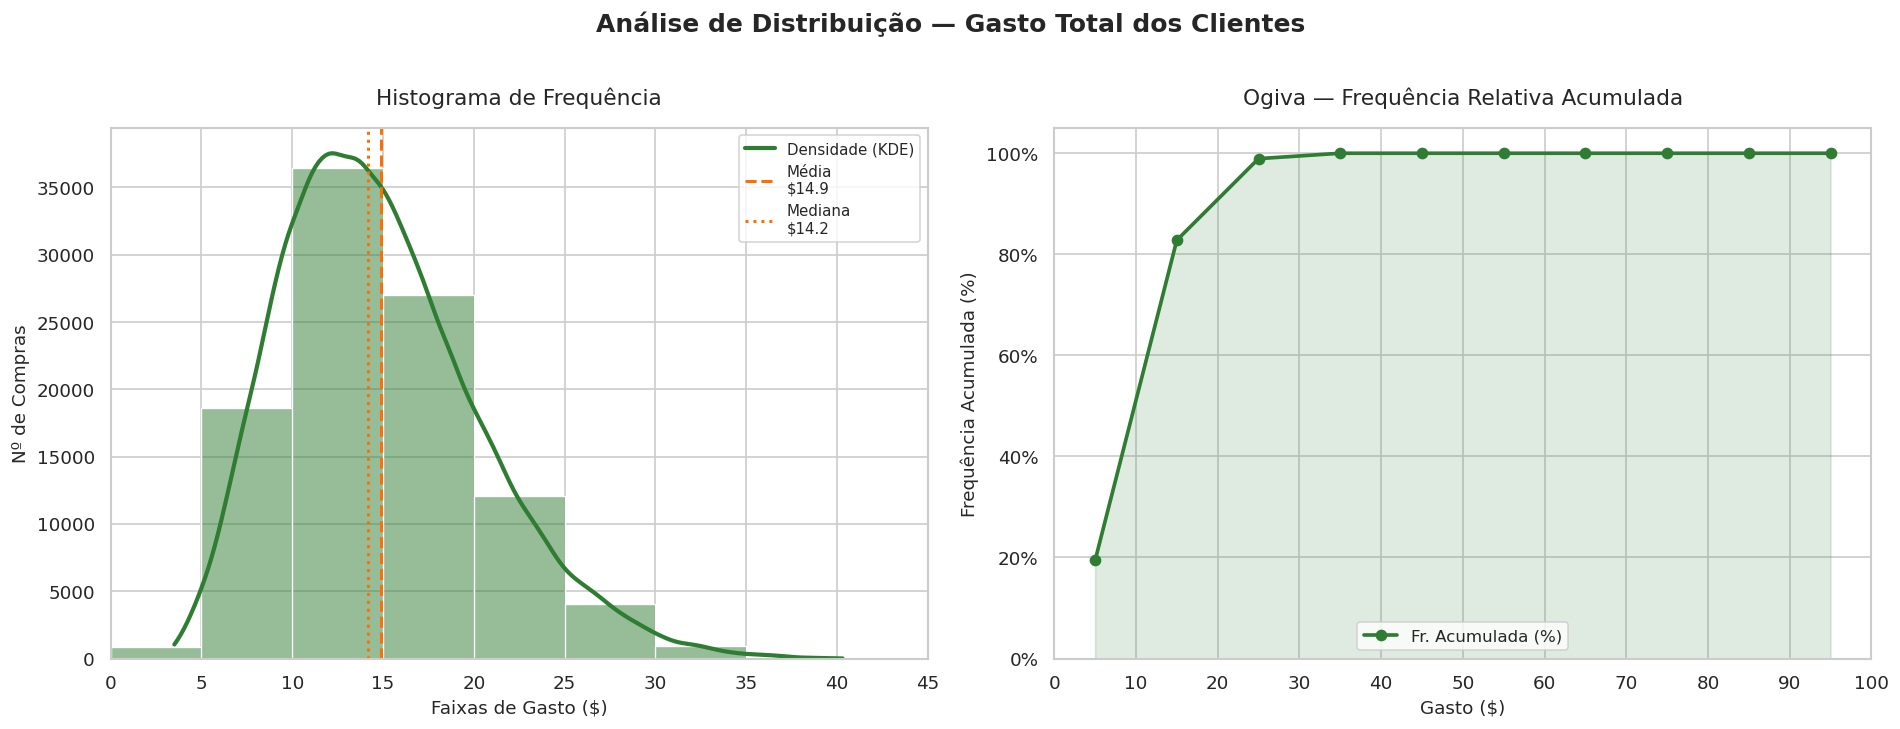


📊 Estatísticas Descritivas — Gasto Total ($)
───────────────────────────────────
  Contagem              : 100000.00
  Média                 :    14.87
  Desvio Padrão         :     5.51
  Mínimo                :     3.51
  Q1 (25%)              :    10.84
  Mediana (50%)         :    14.17
  Q3 (75%)              :    18.18
  Máximo                :    40.31
  Assimetria            :   0.6701
  Curtose               :   0.3775


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titlepad": 14,
})

COLUNA = "total_spend"
INTERVALOS = list(range(0, 101, 10))
LABELS = [f"[{i}, {i+10})" if i < 90 else f"[{i}, {i+10}]"
          for i in range(0, 100, 10)]
COR_PRINCIPAL = "#2e7d32"   # verde escuro
COR_KDE       = "#ff6f00"   # laranja


# ============================================================
# VERIFICAÇÃO DEFENSIVA
# ============================================================
if COLUNA not in df.columns:
    raise KeyError(f"Coluna '{COLUNA}' não encontrada no DataFrame.")

if df[COLUNA].isnull().any():
    n_nulos = df[COLUNA].isnull().sum()
    print(f"⚠️  Atenção: {n_nulos} valor(es) nulo(s) encontrado(s) e ignorado(s).\n")


# ============================================================
# 1. CLASSIFICAÇÃO POR FAIXAS DE GASTO
# ============================================================
df["classe_gasto"] = pd.cut(
    df[COLUNA],
    bins=INTERVALOS,
    labels=LABELS,
    right=False,
    include_lowest=True,   # garante que o valor 100 seja incluído
)


# ============================================================
# 2. TABELA DE FREQUÊNCIA COMPLETA
# ============================================================
fi   = df["classe_gasto"].value_counts().sort_index()
fr   = (fi / fi.sum() * 100).round(2)
fac  = fi.cumsum()                          # Frequência Absoluta Acumulada
frc  = fr.cumsum().round(2)                 # Frequência Relativa Acumulada

tabela = pd.DataFrame({
    "Classes (Gasto $)"            : fi.index,
    "Freq. Absoluta (Fi)"          : fi.values,
    "Freq. Relativa (%)"           : fr.values,
    "Freq. Acumulada (Fac)"        : fac.values,
    "Freq. Relativa Acumulada (%)": frc.values,
})

# Linha de totais
tabela.loc[len(tabela)] = [
    "TOTAL",
    fi.sum(),
    round(fr.sum(), 2),
    "—",
    "—",
]

# Formatação visual (Styler)
styled = (
    tabela.style
    .set_caption("Tabela 1 — Distribuição de Frequência do Gasto Total dos Clientes")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2e7d32"), ("color", "white"),
                   ("text-align", "center"), ("font-size", "12px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("font-size", "12px")]},
    ])
    .apply(lambda x: [
        "background-color: #f1f8e9; font-weight: bold;"
        if x["Classes (Gasto $)"] == "TOTAL" else ""
        for _ in x
    ], axis=1)
    .format({
        "Freq. Absoluta (Fi)"          : "{:,.0f}",
        "Freq. Relativa (%)"           : "{:.2f}%",
    }, na_rep="—")
)

print("\n")
display(styled)


# ============================================================
# 3. VISUALIZAÇÕES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Análise de Distribuição — Gasto Total dos Clientes",
    fontsize=15, fontweight="bold", y=1.01
)

# ── 3A. Histograma com KDE ──────────────────────────────────
ax1 = axes[0]

# Bins ajustados ao range real dos dados
INTERVALOS_PLOT = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]  # granularidade de 5 em 5

sns.histplot(
    df[COLUNA],
    bins=INTERVALOS_PLOT,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white",
    linewidth=0.8,
    line_kws={"color": COR_KDE, "linewidth": 2.5, "label": "Densidade (KDE)"},
    ax=ax1,
)

ax1.set_xticks(INTERVALOS_PLOT)
ax1.set_xlim(0, 45)   # corta o espaço vazio à direita
ax1.set_title("Histograma de Frequência", fontsize=13)
ax1.set_xlabel("Faixas de Gasto ($)", fontsize=11)
ax1.set_ylabel("Nº de Compras", fontsize=11)

# Média e mediana
media   = df[COLUNA].mean()
mediana = df[COLUNA].median()

for val, label, ls in [
    (media,   f"Média\n${media:.1f}",     "--"),
    (mediana, f"Mediana\n${mediana:.1f}", ":"),
]:
    ax1.axvline(val, color=COR_KDE, linestyle=ls, linewidth=1.8, label=label)

ax1.legend(fontsize=9)

# ── 3B. Ogiva (Frequência Acumulada) ───────────────────────
ax2 = axes[1]
midpoints = [(INTERVALOS[i] + INTERVALOS[i+1]) / 2 for i in range(len(INTERVALOS)-1)]
ax2.plot(midpoints, frc.values, marker="o", color=COR_PRINCIPAL,
         linewidth=2.2, markersize=6, label="Fr. Acumulada (%)")
ax2.fill_between(midpoints, frc.values, alpha=0.15, color=COR_PRINCIPAL)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_xticks(INTERVALOS)
ax2.set_title("Ogiva — Frequência Relativa Acumulada", fontsize=13)
ax2.set_xlabel("Gasto ($)", fontsize=11)
ax2.set_ylabel("Frequência Acumulada (%)", fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


# ============================================================
# 4. ESTATÍSTICAS DESCRITIVAS RESUMIDAS
# ============================================================
stats = df[COLUNA].describe().rename({
    "count": "Contagem", "mean": "Média", "std": "Desvio Padrão",
    "min": "Mínimo", "25%": "Q1 (25%)", "50%": "Mediana (50%)",
    "75%": "Q3 (75%)", "max": "Máximo",
})

print("\n📊 Estatísticas Descritivas — Gasto Total ($)")
print("─" * 35)
for nome, valor in stats.items():
    print(f"  {nome:<22}: {valor:>8.2f}")
print(f"  {'Assimetria':<22}: {df[COLUNA].skew():>8.4f}")
print(f"  {'Curtose':<22}: {df[COLUNA].kurt():>8.4f}")


📊 Análise da variável: order_channel


,Categoria,Fi,Fr (%),Fac,Frac (%)
0,Mobile App,42521,42.52,42521,42.52
1,Drive-Thru,27996,28.00,70517,70.52
2,In-Store Cashier,22063,22.06,92580,92.58
3,Kiosk,7420,7.42,100000,100.00


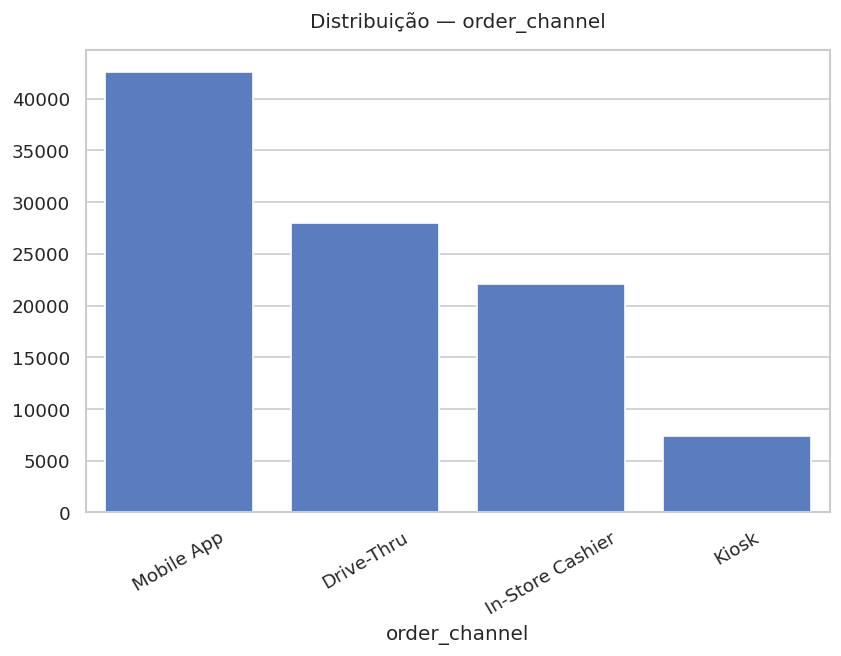


📊 Análise da variável: store_location_type


,Categoria,Fi,Fr (%),Fac,Frac (%)
0,Suburban,35696,35.70,35696,35.70
1,Urban,32584,32.58,68280,68.28
2,Rural,31720,31.72,100000,100.00


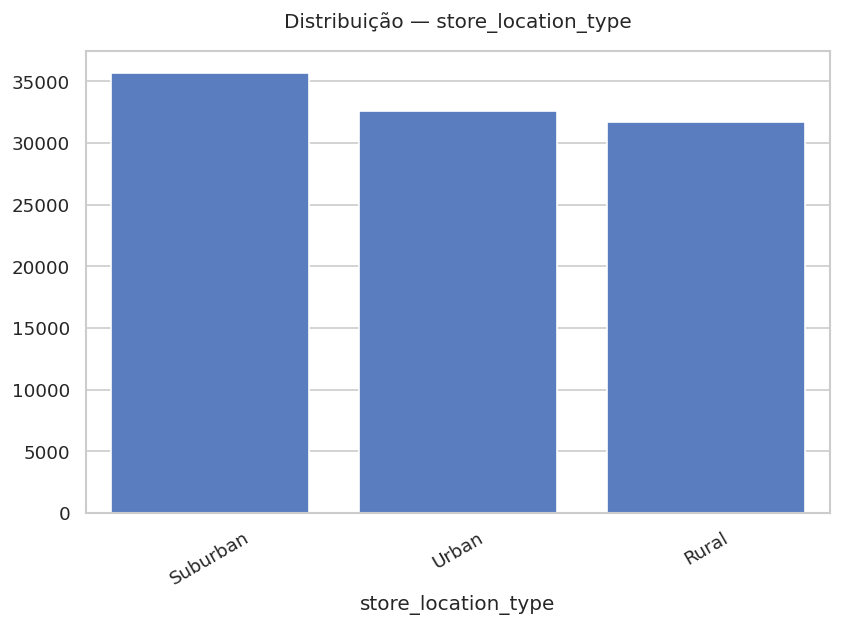


📊 Análise da variável: customer_age_group


,Categoria,Fi,Fr (%),Fac,Frac (%)
0,25-34,29782,29.78,29782,29.78
1,35-44,24543,24.54,54325,54.32
2,18-24,20274,20.27,74599,74.59
3,45-54,15382,15.38,89981,89.97
4,55+,10019,10.02,100000,99.99


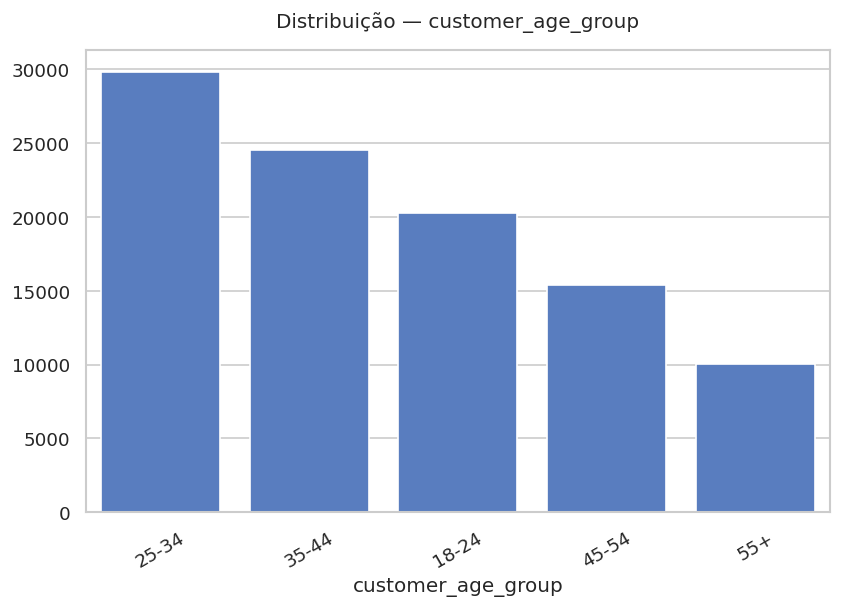


📊 Análise da variável: is_rewards_member


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(0.0, 0.222]",0,0.0,0,0.0
1,"(0.222, 0.444]",0,0.0,0,0.0
2,"(0.444, 0.667]",0,0.0,0,0.0
3,"(0.667, 0.889]",0,0.0,0,0.0
4,"(0.889, 1.111]",47717,100.0,47717,100.0
5,"(1.111, 1.333]",0,0.0,47717,100.0
6,"(1.333, 1.556]",0,0.0,47717,100.0
7,"(1.556, 1.778]",0,0.0,47717,100.0
8,"(1.778, 2.0]",0,0.0,47717,100.0


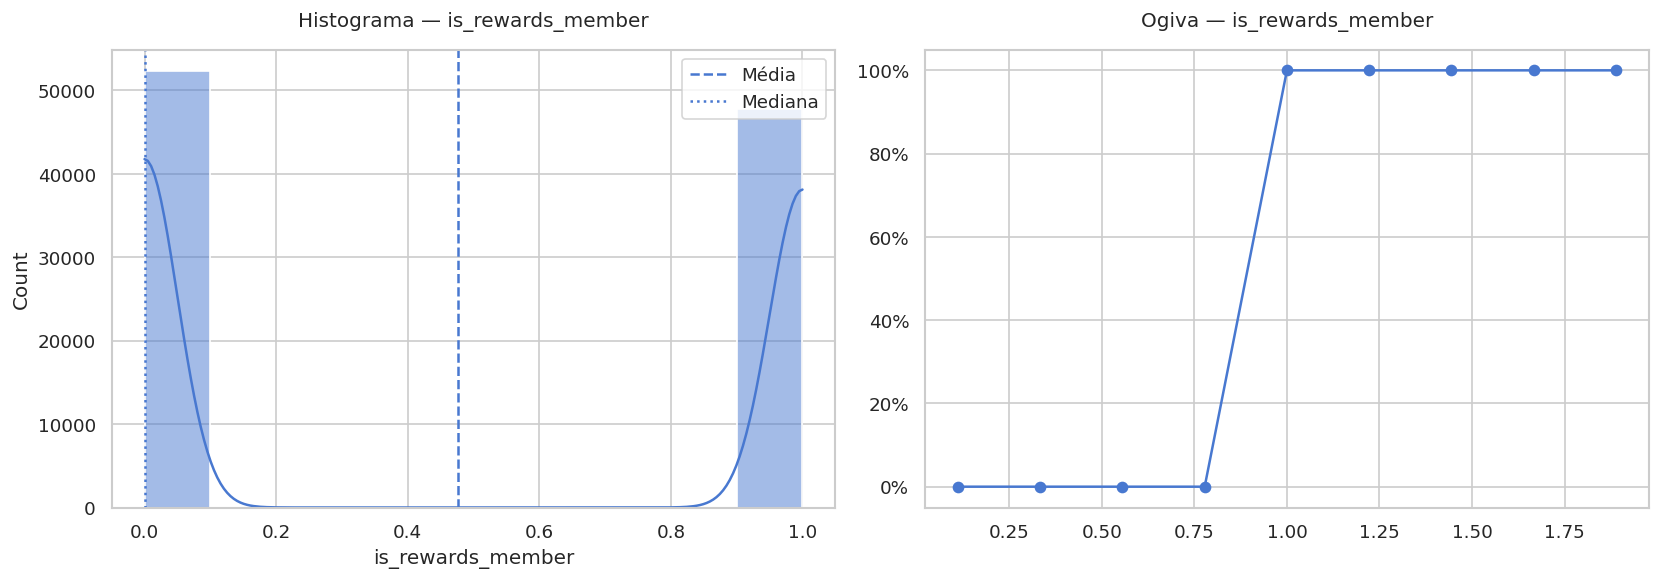

📌 Estatísticas:
count     100000
unique         2
top        False
freq       52283
Name: is_rewards_member, dtype: object
Assimetria: 0.09141671395623775
Curtose: -1.9916828184658246

📊 Análise da variável: has_food_item


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(0.0, 0.222]",0,0.0,0,0.0
1,"(0.222, 0.444]",0,0.0,0,0.0
2,"(0.444, 0.667]",0,0.0,0,0.0
3,"(0.667, 0.889]",0,0.0,0,0.0
4,"(0.889, 1.111]",31581,100.0,31581,100.0
5,"(1.111, 1.333]",0,0.0,31581,100.0
6,"(1.333, 1.556]",0,0.0,31581,100.0
7,"(1.556, 1.778]",0,0.0,31581,100.0
8,"(1.778, 2.0]",0,0.0,31581,100.0


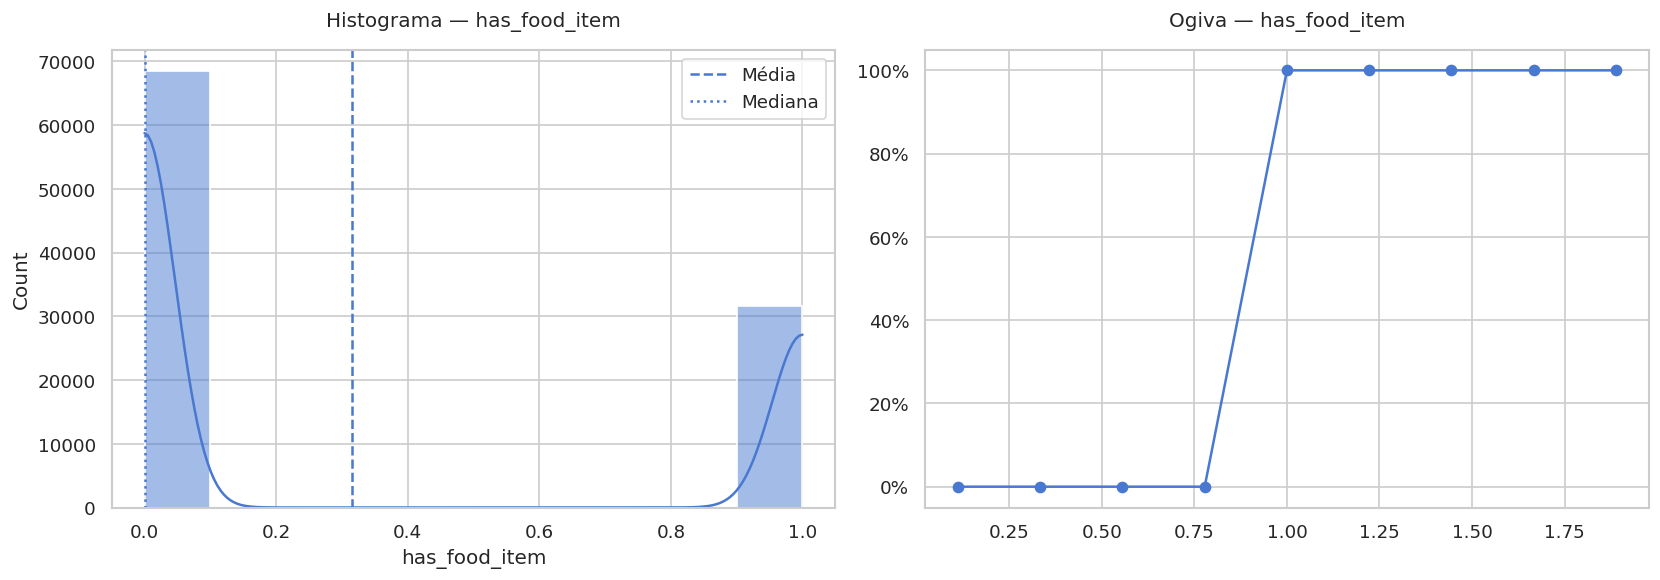

📌 Estatísticas:
count     100000
unique         2
top        False
freq       68419
Name: has_food_item, dtype: object
Assimetria: 0.7925036261850678
Curtose: -1.3719654421923724

📊 Análise da variável: order_ahead


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(0.0, 0.222]",0,0.0,0,0.0
1,"(0.222, 0.444]",0,0.0,0,0.0
2,"(0.444, 0.667]",0,0.0,0,0.0
3,"(0.667, 0.889]",0,0.0,0,0.0
4,"(0.889, 1.111]",29793,100.0,29793,100.0
5,"(1.111, 1.333]",0,0.0,29793,100.0
6,"(1.333, 1.556]",0,0.0,29793,100.0
7,"(1.556, 1.778]",0,0.0,29793,100.0
8,"(1.778, 2.0]",0,0.0,29793,100.0


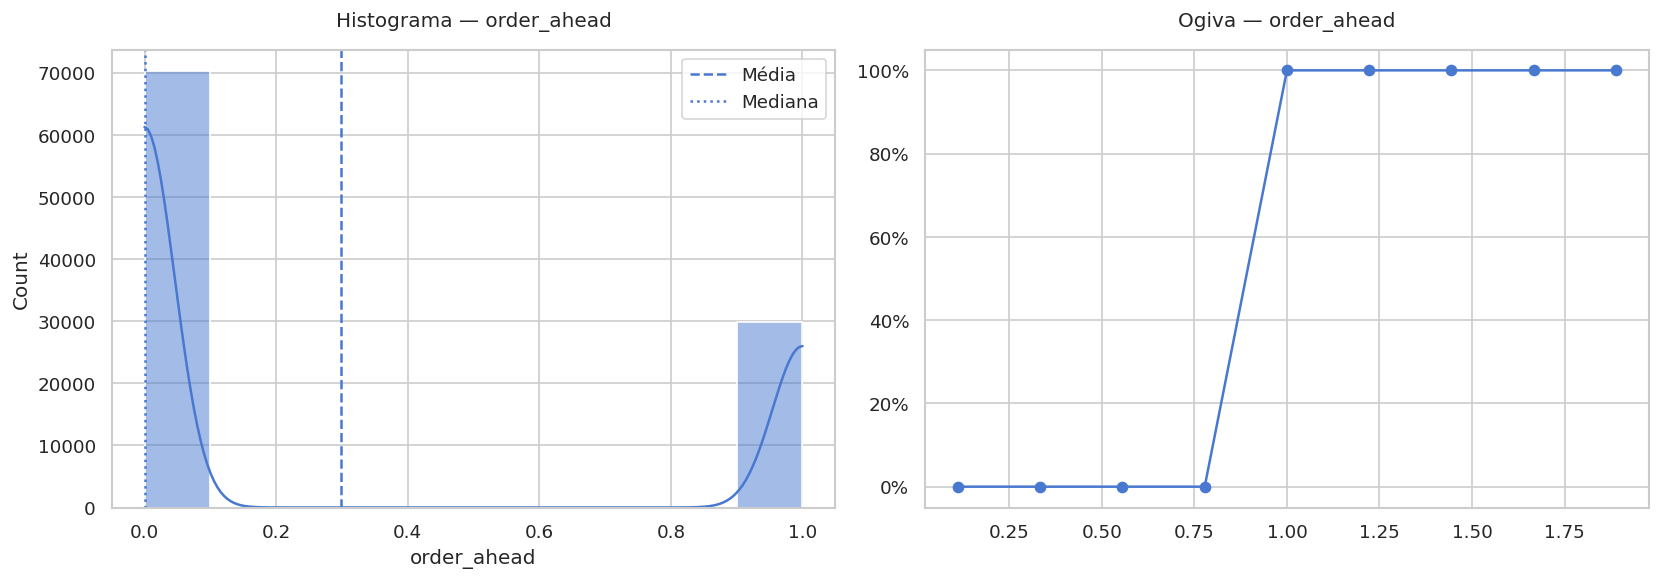

📌 Estatísticas:
count     100000
unique         2
top        False
freq       70207
Name: order_ahead, dtype: object
Assimetria: 0.8836718602142597
Curtose: -1.219148426834015

📊 Análise da variável: cart_size


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(1.0, 2.111]",18079,19.41,18079,19.41
1,"(2.111, 3.222]",23982,25.75,42061,45.16
2,"(3.222, 4.333]",21615,23.20,63676,68.36
3,"(4.333, 5.444]",14572,15.64,78248,84.00
4,"(5.444, 6.556]",8226,8.83,86474,92.83
5,"(6.556, 7.667]",4081,4.38,90555,97.21
6,"(7.667, 8.778]",1696,1.82,92251,99.03
7,"(8.778, 9.889]",613,0.66,92864,99.69
8,"(9.889, 11.0]",287,0.31,93151,100.00


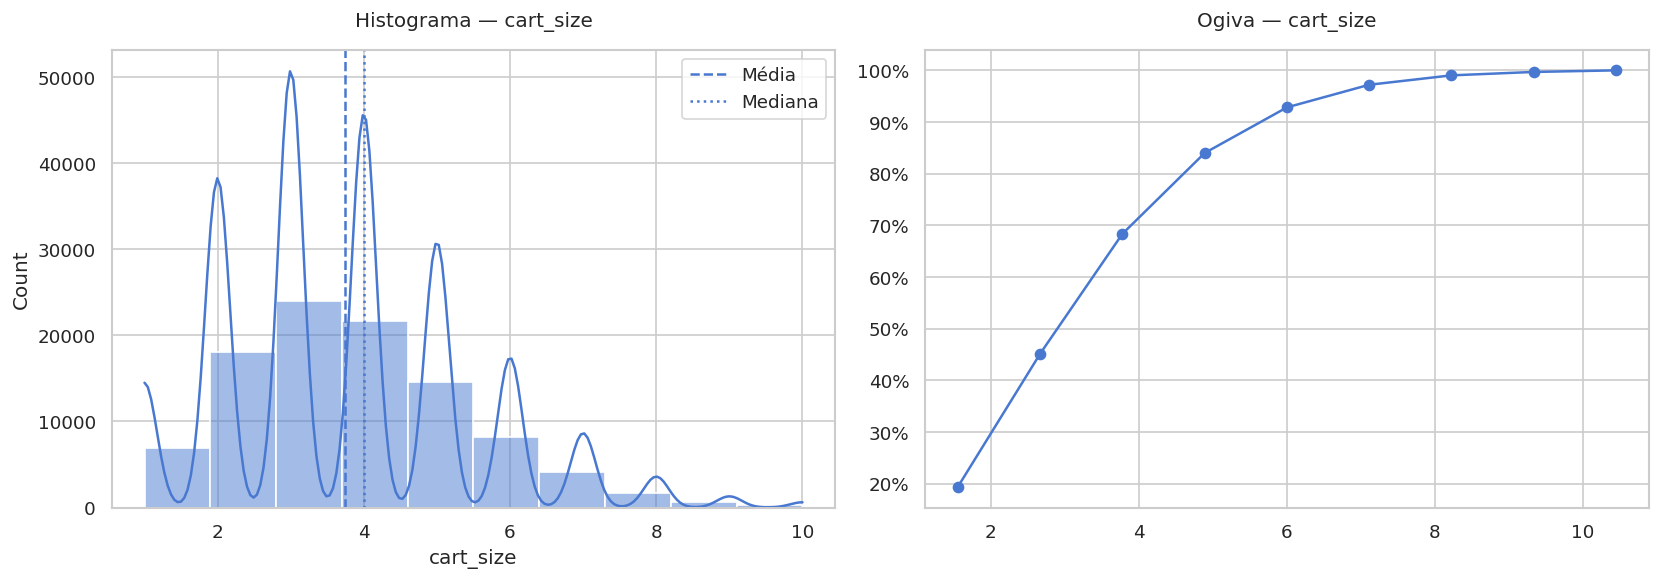

📌 Estatísticas:
count    100000.000000
mean          3.741510
std           1.697817
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max          10.000000
Name: cart_size, dtype: float64
Assimetria: 0.6323145179389259
Curtose: 0.2952150389693404

📊 Análise da variável: num_customizations


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(0.0, 1.0]",29006,35.84,29006,35.84
1,"(1.0, 2.0]",24319,30.05,53325,65.89
2,"(2.0, 3.0]",14841,18.34,68166,84.23
3,"(3.0, 4.0]",7552,9.33,75718,93.56
4,"(4.0, 5.0]",3343,4.13,79061,97.69
5,"(5.0, 6.0]",1261,1.56,80322,99.25
6,"(6.0, 7.0]",451,0.56,80773,99.81
7,"(7.0, 8.0]",158,0.20,80931,100.01
8,"(8.0, 9.0]",0,0.00,80931,100.01


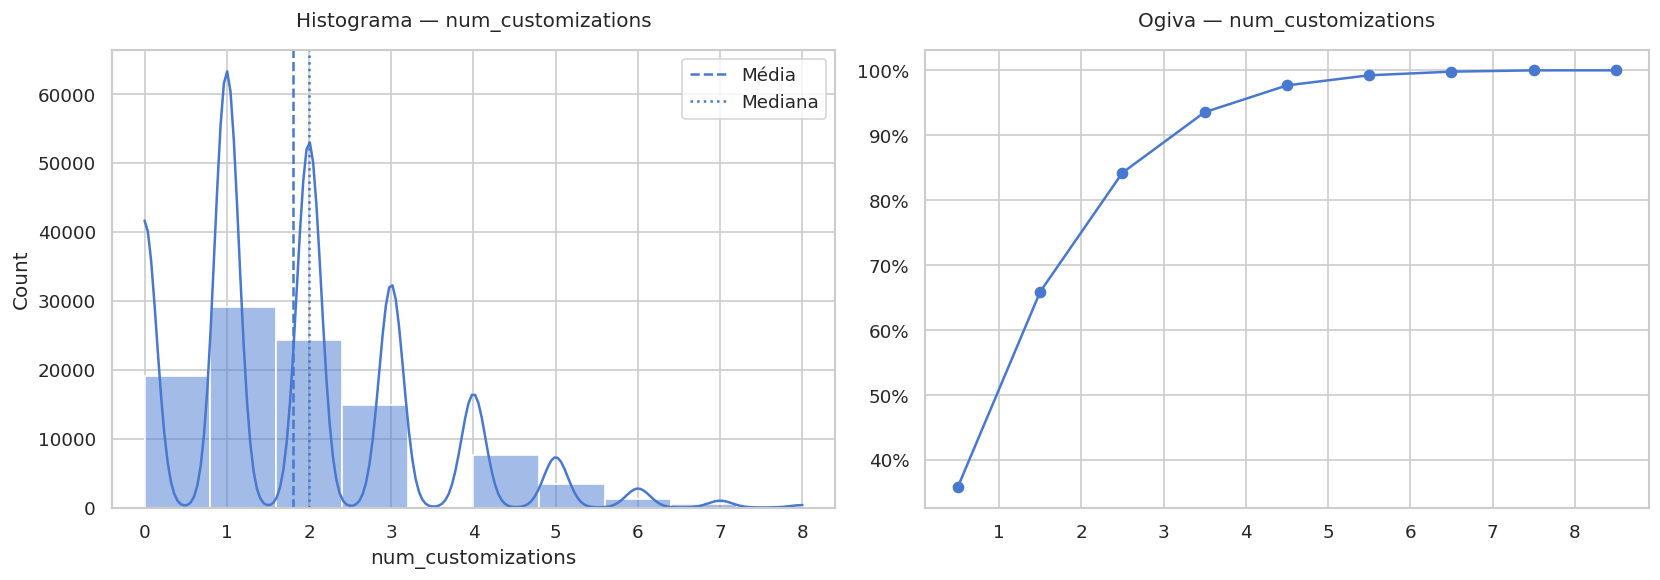

📌 Estatísticas:
count    100000.00000
mean          1.81077
std           1.46280
min           0.00000
25%           1.00000
50%           2.00000
75%           3.00000
max           8.00000
Name: num_customizations, dtype: float64
Assimetria: 0.8860013811956152
Curtose: 0.7432456424750975

📊 Análise da variável: total_spend


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(3.0, 7.222]",5556,5.56,5556,5.56
1,"(7.222, 11.444]",24113,24.11,29669,29.67
2,"(11.444, 15.667]",30727,30.73,60396,60.40
3,"(15.667, 19.889]",22028,22.03,82424,82.43
4,"(19.889, 24.111]",11155,11.16,93579,93.59
5,"(24.111, 28.333]",4544,4.54,98123,98.13
6,"(28.333, 32.556]",1462,1.46,99585,99.59
7,"(32.556, 36.778]",366,0.37,99951,99.96
8,"(36.778, 41.0]",49,0.05,100000,100.01


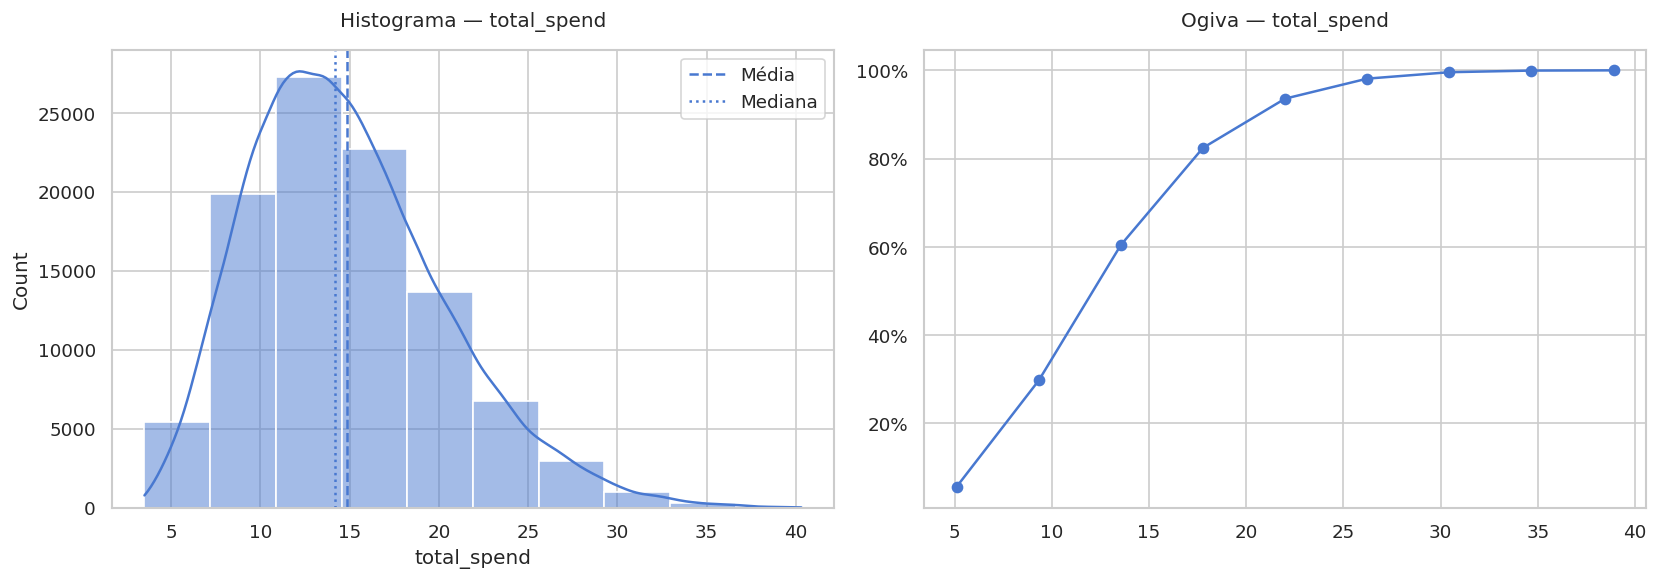

📌 Estatísticas:
count    100000.000000
mean         14.866771
std           5.506800
min           3.510000
25%          10.837500
50%          14.170000
75%          18.180000
max          40.310000
Name: total_spend, dtype: float64
Assimetria: 0.6700890604294385
Curtose: 0.377541757926378

📊 Análise da variável: fulfillment_time_min


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(1.0, 2.222]",5518,5.54,5518,5.54
1,"(2.222, 3.444]",19416,19.48,24934,25.02
2,"(3.444, 4.667]",29950,30.05,54884,55.07
3,"(4.667, 5.889]",25059,25.15,79943,80.22
4,"(5.889, 7.111]",13884,13.93,93827,94.15
5,"(7.111, 8.333]",4568,4.58,98395,98.73
6,"(8.333, 9.556]",1101,1.10,99496,99.83
7,"(9.556, 10.778]",146,0.15,99642,99.98
8,"(10.778, 12.0]",12,0.01,99654,99.99


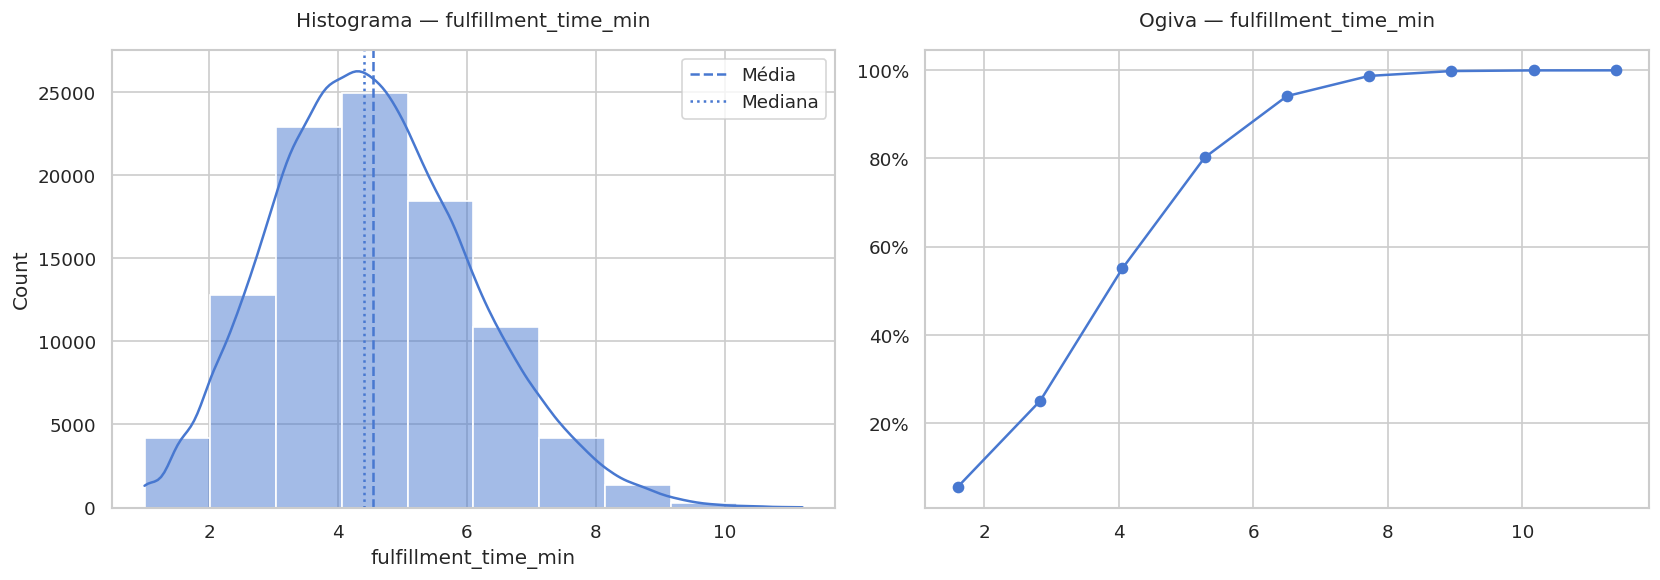

📌 Estatísticas:
count    100000.000000
mean          4.546080
std           1.550269
min           1.000000
25%           3.400000
50%           4.400000
75%           5.500000
max          11.200000
Name: fulfillment_time_min, dtype: float64
Assimetria: 0.36377302856701754
Curtose: -0.018345381487461676

📊 Análise da variável: customer_satisfaction


,Classe,Fi,Fr (%),Fac,Frac (%)
0,"(1.0, 1.556]",0,0.00,0,0.00
1,"(1.556, 2.111]",11542,12.32,11542,12.32
2,"(2.111, 2.667]",0,0.00,11542,12.32
3,"(2.667, 3.222]",18222,19.45,29764,31.77
4,"(3.222, 3.778]",0,0.00,29764,31.77
5,"(3.778, 4.333]",35001,37.35,64765,69.12
6,"(4.333, 4.889]",0,0.00,64765,69.12
7,"(4.889, 5.444]",28941,30.88,93706,100.00
8,"(5.444, 6.0]",0,0.00,93706,100.00


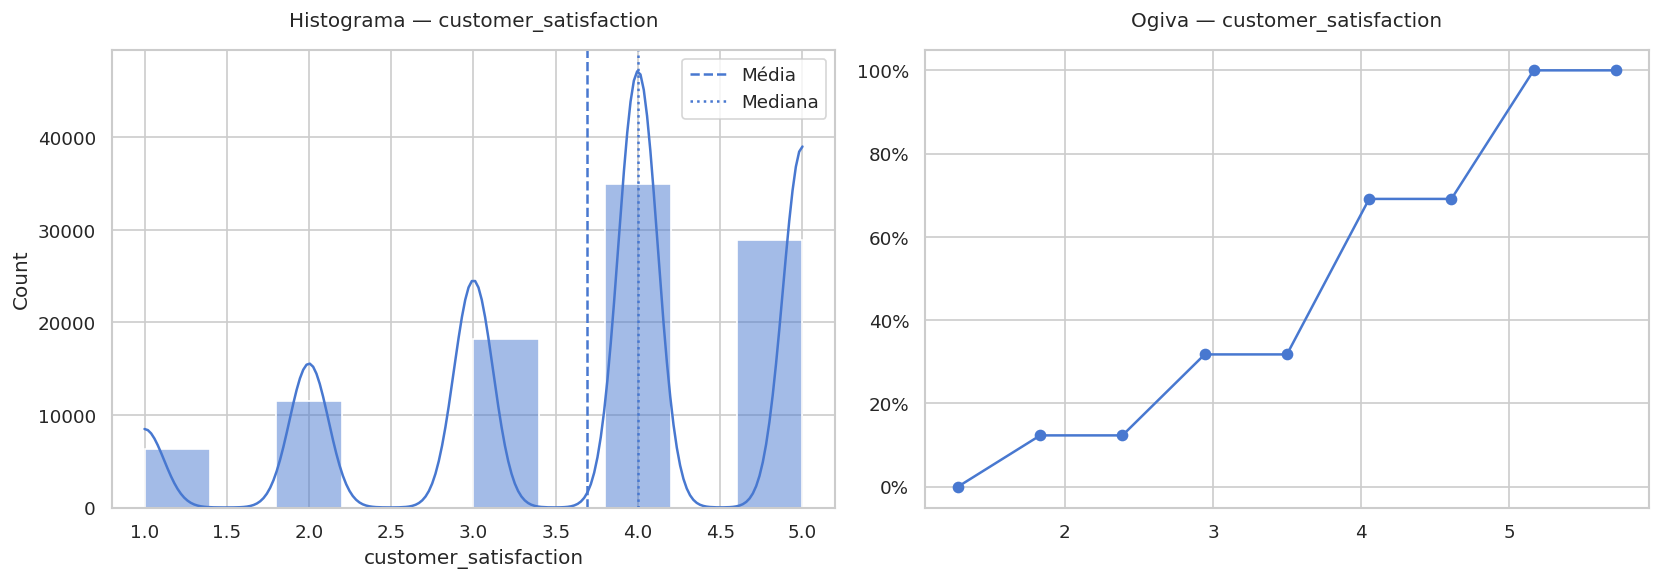

📌 Estatísticas:
count    100000.000000
mean          3.687530
std           1.184123
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: customer_satisfaction, dtype: float64
Assimetria: -0.7051097930139116
Curtose: -0.3944553451013646


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")

# ================= DATAFRAME =================
df_model = df[['order_channel',
               'store_location_type',
               'customer_age_group',
               'is_rewards_member',
               'has_food_item',
               'order_ahead',
               'cart_size',
               'num_customizations',
               'total_spend',
               'fulfillment_time_min',
               'customer_satisfaction']].copy()

# ================= LOOP PRINCIPAL =================
for coluna in df_model.columns:

    print("\n" + "="*60)
    print(f"📊 Análise da variável: {coluna}")
    print("="*60)

    serie = df_model[coluna].dropna()

    # ============================================================
    # CASO 1: VARIÁVEL NUMÉRICA
    # ============================================================
    if pd.api.types.is_numeric_dtype(serie):

        # Criar intervalos automaticamente
        minimo = int(serie.min())
        maximo = int(serie.max()) + 1
        bins = np.linspace(minimo, maximo, 10)

        classes = pd.cut(serie, bins=bins)

        fi = classes.value_counts().sort_index()
        fr = (fi / fi.sum() * 100).round(2)
        fac = fi.cumsum()
        frc = fr.cumsum().round(2)

        tabela = pd.DataFrame({
            "Classe": fi.index.astype(str),
            "Fi": fi.values,
            "Fr (%)": fr.values,
            "Fac": fac.values,
            "Frac (%)": frc.values
        })

        display(tabela)

        # ================= GRÁFICOS =================
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histograma
        sns.histplot(serie, bins=10, kde=True, ax=axes[0])
        axes[0].set_title(f"Histograma — {coluna}")

        media = serie.mean()
        mediana = serie.median()

        axes[0].axvline(media, linestyle="--", label="Média")
        axes[0].axvline(mediana, linestyle=":", label="Mediana")
        axes[0].legend()

        # Ogiva
        midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

        axes[1].plot(midpoints, frc.values, marker="o")
        axes[1].set_title(f"Ogiva — {coluna}")
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

        plt.tight_layout()
        plt.show()

        # ================= ESTATÍSTICAS =================
        print("📌 Estatísticas:")
        print(serie.describe())
        print("Assimetria:", serie.skew())
        print("Curtose:", serie.kurt())

    # ============================================================
    # CASO 2: VARIÁVEL CATEGÓRICA
    # ============================================================
    else:

        fi = serie.value_counts()
        fr = (fi / fi.sum() * 100).round(2)
        fac = fi.cumsum()
        frc = fr.cumsum().round(2)

        tabela = pd.DataFrame({
            "Categoria": fi.index,
            "Fi": fi.values,
            "Fr (%)": fr.values,
            "Fac": fac.values,
            "Frac (%)": frc.values
        })

        display(tabela)

        # ================= GRÁFICO =================
        plt.figure(figsize=(8, 5))
        sns.barplot(x=fi.index, y=fi.values)
        plt.title(f"Distribuição — {coluna}")
        plt.xticks(rotation=30)
        plt.show()


# 📊 Medidas Estatísticas para Análise de Dados

Algumas medidas podem ser utilizadas para **resumir a informação** contida em uma  
distribuição de probabilidade de um atributo ou em uma base de dados.

Essas medidas permitem compreender melhor o comportamento dos dados, facilitando a análise.

---

## 🔎 Tipos de Medidas Estatísticas

### 📍 1. Medidas de Tendência Central
Representam o valor central ou típico dos dados.

- Média
- Mediana
- Moda

---

### 📏 2. Medidas de Dispersão
Indicam o grau de variação ou espalhamento dos dados.

- Variância
- Desvio padrão
- Amplitude

---

### 📈 3. Medidas de Forma da Distribuição
Descrevem o formato da distribuição dos dados.

- Assimetria (*Skewness*)
- Curtose

---

In [9]:
# -------------------------
# Selecionar colunas
# -------------------------
df_model = df[['order_channel',
               'store_location_type',
               'customer_age_group',
               'is_rewards_member',
               'has_food_item',
               'order_ahead',
               'cart_size',
               'num_customizations',
               'total_spend',
               'fulfillment_time_min',
               'customer_satisfaction']].copy()

num_cols = df_model.select_dtypes(include=['int64', 'float64'])
cat_cols = df_model.select_dtypes(include=['object', 'bool', 'category'])

# Média, mediana e moda
medidas_numericas = num_cols.agg(['mean', 'median'])
moda_numericas = num_cols.mode().iloc[0]

print("Medidas Numéricas:")
display(medidas_numericas)

print("\nModa:")
display(moda_numericas)

moda_categoricas = cat_cols.mode().iloc[0]

print("Moda das Variáveis Categóricas:")
display(moda_categoricas)



/tmp/xpython_42/188818323.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include=['object', 'bool', 'category'])


Medidas Numéricas:


,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
mean,3.74151,1.81077,14.866771,4.54608,3.68753
median,4.00000,2.00000,14.170000,4.40000,4.00000



Moda:


cart_size                 3.00
num_customizations        1.00
total_spend              12.04
fulfillment_time_min      4.30
customer_satisfaction     4.00
Name: 0, dtype: float64

Moda das Variáveis Categóricas:


order_channel          Mobile App
store_location_type      Suburban
customer_age_group          25-34
is_rewards_member           False
has_food_item               False
order_ahead                 False
Name: 0, dtype: object

In [10]:
# Criar tabela resumo
resumo = pd.DataFrame()

# Numéricas
resumo['mean'] = num_cols.mean()
resumo['median'] = num_cols.median()
resumo['mode'] = num_cols.mode().iloc[0]

# Categóricas (só moda)
resumo_cat = pd.DataFrame()
resumo_cat['mode'] = cat_cols.mode().iloc[0]

# Juntar tudo
resumo_final = pd.concat([resumo, resumo_cat])

display(resumo_final)

,mean,median,mode
cart_size,3.741510,4.00,3.0
num_customizations,1.810770,2.00,1.0
total_spend,14.866771,14.17,12.04
fulfillment_time_min,4.546080,4.40,4.3
customer_satisfaction,3.687530,4.00,4.0
order_channel,NaN,NaN,Mobile App
store_location_type,NaN,NaN,Suburban
customer_age_group,NaN,NaN,25-34
is_rewards_member,NaN,NaN,False
has_food_item,NaN,NaN,False
